<a href="https://colab.research.google.com/github/devwoo41/Experiments/blob/master/GAN/gan_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative Adversarial Nets — 논문 재현

**Paper**: Goodfellow et al., *Generative Adversarial Nets*, NeurIPS 2014. [arXiv:1406.2661](https://arxiv.org/abs/1406.2661)

**목표**
- 논문 Algorithm 1 을 그대로 구현한다.
- 데이터: **MNIST**.
- 아키텍처: 논문대로 **MLP** — G 는 ReLU + sigmoid, D 는 **Maxout + dropout** (논문 §4 / 부록).
- 평가:
  1. 학습 중 sample grid + G/D loss curves.
  2. **Parzen window log-likelihood** (논문 Table 1 의 metric).
- 추가: GAN 특유의 학습 불안정성 — **saturating vs non-saturating G loss**, **D 우세로 인한 G gradient 소실**, **mode collapse** — 의도적으로 재현해 본다.

**런타임**: Colab 무료 T4 / Pro A100 모두 OK. MNIST + MLP 면 T4 에서 60 epoch ≈ 15\~20 분.

## 0. 환경 설정

In [1]:
!nvidia-smi

Sat May 16 05:17:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import math, time, os, random
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0); np.random.seed(0); random.seed(0)
print('device =', device, '| torch =', torch.__version__)

device = cuda | torch = 2.10.0+cu128


## 1. 논문 개요

**Two-player minimax game** (Eq. 1):
$$\min_G \max_D \;\; V(D, G) \;=\; \mathbb{E}_{x\sim p_{\text{data}}}\big[\log D(x)\big] \;+\; \mathbb{E}_{z\sim p_z}\big[\log(1 - D(G(z)))\big].$$

**Algorithm 1** — minibatch SGD 로 G/D 를 교대로 업데이트:
1. $k$ steps for D — D 의 목적함수 $\nabla_{\theta_d}\frac{1}{m}\sum_i [\log D(x^{(i)}) + \log(1 - D(G(z^{(i)})))]$ 를 **상승**.
2. 1 step for G — $\nabla_{\theta_g}\frac{1}{m}\sum_i \log(1 - D(G(z^{(i)})))$ 를 **하강**.
3. 논문은 실험에서 $k=1$ 을 사용.

**Non-saturating G loss (논문 §3)**.  학습 초기에 $D$ 가 $G(z)$ 를 쉽게 구별하면 $\log(1 - D(G(z)))$ 가 saturate 해서 $G$ 의 gradient 가 사라진다. 그래서 실제로는
$$\max_G \;\; \mathbb{E}_{z}\big[\log D(G(z))\big]$$
로 G 를 학습한다 (같은 fixed point 에 도달하지만 gradient 가 훨씬 큼). 이번 노트북은 이 non-saturating 변형을 default 로 쓰고, §9 에서 saturating 변형과 비교한다.

**Global optimum** (Proposition 2): 위 게임의 fixed point 에서 $p_g = p_{\text{data}}$, $D^*(x) = 1/2$, $C(G) = -\log 4$.

## 2. 데이터 — MNIST

픽셀은 $[0, 1]$ 로 정규화. G 의 출력이 sigmoid 라 같은 range.

100%|██████████| 9.91M/9.91M [00:00<00:00, 64.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.63MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.7MB/s]

train = 60000 | test = 10000


x torch.Size([100, 1, 28, 28]) min 0.0 max 1.0


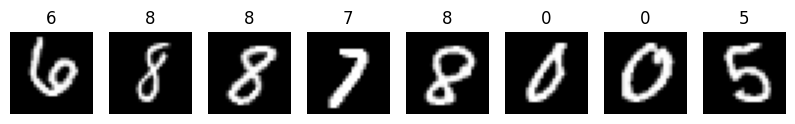

In [3]:
transform = transforms.Compose([transforms.ToTensor()])    # → [0, 1]
train_ds = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_ds  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

BATCH = 100   # 논문
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=1000, shuffle=False, num_workers=2, pin_memory=True)
print('train =', len(train_ds), '| test =', len(test_ds))

x, y = next(iter(train_loader))
print('x', x.shape, 'min', x.min().item(), 'max', x.max().item())
fig, axes = plt.subplots(1, 8, figsize=(10, 1.5))
for i, ax in enumerate(axes):
    ax.imshow(x[i, 0].numpy(), cmap='gray'); ax.axis('off'); ax.set_title(int(y[i]))
plt.show()

## 3. Maxout 정의

Goodfellow et al. (ICML 2013) 의 Maxout — D 의 hidden activation 으로 논문이 명시적으로 사용 (§4: *"The discriminator net used maxout activations"*).

한 maxout unit 은 $k$ 개의 affine piece 중 element-wise 최댓값:
$$h_j(x) \;=\; \max_{i \in \{1,\dots,k\}} (W_{ij}^\top x + b_{ij}).$$
Piecewise linear, 어떤 convex function 도 근사할 수 있는 보편 근사.

In [4]:
class Maxout(nn.Module):
    def __init__(self, in_features: int, out_features: int, num_pieces: int = 5):
        super().__init__()
        self.out_features = out_features
        self.num_pieces = num_pieces
        self.fc = nn.Linear(in_features, out_features * num_pieces)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.fc(x)                                          # [B, out * k]
        z = z.view(-1, self.out_features, self.num_pieces)       # [B, out, k]
        return z.max(dim=-1).values                              # [B, out]

print(Maxout(784, 240, 5)(torch.randn(4, 784)).shape)

torch.Size([4, 240])


## 4. Generator (MLP)

논문 부록 셋팅에 가깝게: $z \in \mathbb{R}^{100}$, $z_i \sim \mathcal{U}(-1, 1)$ → 1200 ReLU → 1200 ReLU → 784 sigmoid.

In [5]:
Z_DIM = 100

class Generator(nn.Module):
    def __init__(self, z_dim: int = Z_DIM, hidden: int = 1200, img_dim: int = 28*28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden),  nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, img_dim), nn.Sigmoid(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)

def sample_z(batch: int, z_dim: int = Z_DIM, device=device) -> torch.Tensor:
    return torch.empty(batch, z_dim, device=device).uniform_(-1.0, 1.0)

_g = Generator().to(device)
print('G params =', sum(p.numel() for p in _g.parameters())/1e6, 'M')
del _g

G params = 2.503984 M


## 5. Discriminator (Maxout MLP + dropout)

논문: D 는 maxout activation, 입력/은닉에 dropout. 출력은 1-d sigmoid (real 확률).

In [6]:
class Discriminator(nn.Module):
    def __init__(self, img_dim: int = 28*28, hidden: int = 240, num_pieces: int = 5, p_drop: float = 0.5):
        super().__init__()
        self.drop_in = nn.Dropout(p_drop)
        self.m1 = Maxout(img_dim, hidden, num_pieces)
        self.drop1 = nn.Dropout(p_drop)
        self.m2 = Maxout(hidden, hidden, num_pieces)
        self.drop2 = nn.Dropout(p_drop)
        self.out = nn.Linear(hidden, 1)

    def forward(self, x: torch.Tensor, return_logits: bool = False) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = self.drop_in(x)
        x = self.drop1(self.m1(x))
        x = self.drop2(self.m2(x))
        logit = self.out(x).squeeze(-1)
        return logit if return_logits else torch.sigmoid(logit)

_d = Discriminator().to(device)
print('D params =', sum(p.numel() for p in _d.parameters())/1e6, 'M')
del _d

D params = 1.231441 M


## 6. 학습 — Algorithm 1

**Loss**:
- D: BCE 두 항. $-(\log D(x) + \log(1 - D(G(z))))$ 를 **최소화**.  PyTorch 의 `BCEWithLogitsLoss` 로 stable 하게 구현.
- G (non-saturating): $-\log D(G(z))$ 를 **최소화**.

**Optimizer**: 논문은 SGD + momentum 을 썼지만 lr/스케줄에 매우 민감해서 modern 재현은 보통 **Adam(lr=2e-4, betas=(0.5, 0.999))** 를 쓴다 (Radford et al. 2015 의 DCGAN 설정).  여기서도 안정성을 위해 Adam.

**$k$ steps for D**: 논문이 $k=1$ 을 썼으므로 동일.

In [7]:
@dataclass
class TrainConfig:
    epochs: int = 60
    lr_g: float = 2e-4
    lr_d: float = 2e-4
    betas: tuple = (0.5, 0.999)
    k_d_steps: int = 1
    g_loss_type: str = 'non_saturating'   # or 'saturating'
    sample_every: int = 5
    tag: str = 'default'

def make_models():
    return Generator().to(device), Discriminator().to(device)

def d_loss(D: nn.Module, x_real: torch.Tensor, x_fake: torch.Tensor) -> Tuple[torch.Tensor, dict]:
    bce = F.binary_cross_entropy_with_logits
    logits_real = D(x_real, return_logits=True)
    logits_fake = D(x_fake, return_logits=True)
    loss_real = bce(logits_real, torch.ones_like(logits_real))
    loss_fake = bce(logits_fake, torch.zeros_like(logits_fake))
    loss = loss_real + loss_fake
    with torch.no_grad():
        D_x  = torch.sigmoid(logits_real).mean().item()
        D_Gz = torch.sigmoid(logits_fake).mean().item()
    return loss, {'D_x': D_x, 'D_Gz': D_Gz}

def g_loss(D: nn.Module, x_fake: torch.Tensor, kind: str = 'non_saturating') -> torch.Tensor:
    logits = D(x_fake, return_logits=True)
    if kind == 'non_saturating':
        # max E[log D(G(z))]  ⇔  BCE(logits, 1)
        return F.binary_cross_entropy_with_logits(logits, torch.ones_like(logits))
    elif kind == 'saturating':
        # 논문 Eq.1 원형: min E[log(1 - D(G(z)))]  =  softplus(logits) 평균
        return F.softplus(logits).mean()
    else:
        raise ValueError(kind)

def train(cfg: TrainConfig):
    G, D = make_models()
    opt_G = torch.optim.Adam(G.parameters(), lr=cfg.lr_g, betas=cfg.betas)
    opt_D = torch.optim.Adam(D.parameters(), lr=cfg.lr_d, betas=cfg.betas)

    history = {'g_loss': [], 'd_loss': [], 'D_x': [], 'D_Gz': [], 'epoch_samples': {}}
    fixed_z = sample_z(64)

    for ep in range(1, cfg.epochs + 1):
        G.train(); D.train()
        t0 = time.time()
        for x_real, _ in train_loader:
            x_real = x_real.to(device, non_blocking=True)
            B = x_real.size(0)

            # (k) D updates
            for _ in range(cfg.k_d_steps):
                z = sample_z(B)
                with torch.no_grad():
                    x_fake = G(z).view(B, 1, 28, 28)
                loss_d, stat = d_loss(D, x_real, x_fake)
                opt_D.zero_grad(set_to_none=True); loss_d.backward(); opt_D.step()

            # 1 G update
            z = sample_z(B)
            x_fake = G(z).view(B, 1, 28, 28)
            loss_g = g_loss(D, x_fake, cfg.g_loss_type)
            opt_G.zero_grad(set_to_none=True); loss_g.backward(); opt_G.step()

            history['g_loss'].append(float(loss_g))
            history['d_loss'].append(float(loss_d))
            history['D_x'].append(stat['D_x']); history['D_Gz'].append(stat['D_Gz'])

        if ep == 1 or ep % cfg.sample_every == 0 or ep == cfg.epochs:
            G.eval()
            with torch.no_grad():
                imgs = G(fixed_z).view(-1, 1, 28, 28).cpu()
            history['epoch_samples'][ep] = imgs

        n = len(train_loader)
        print(f'[{cfg.tag}] epoch {ep:3d}'
              f'  d={np.mean(history["d_loss"][-n:]):.3f}'
              f'  g={np.mean(history["g_loss"][-n:]):.3f}'
              f'  D(x)={np.mean(history["D_x"][-n:]):.3f}'
              f'  D(G(z))={np.mean(history["D_Gz"][-n:]):.3f}'
              f'  ({time.time()-t0:.1f}s)')

    return G, D, history

In [8]:
cfg = TrainConfig(epochs=60, tag='vanilla')
G, D, hist = train(cfg)

/tmp/ipykernel_21560/2167141812.py:67: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  history['g_loss'].append(float(loss_g))


[vanilla] epoch   1  d=0.600  g=2.836  D(x)=0.805  D(G(z))=0.230  (5.6s)
[vanilla] epoch   2  d=0.207  g=5.097  D(x)=0.942  D(G(z))=0.069  (4.5s)
[vanilla] epoch   3  d=0.136  g=5.863  D(x)=0.962  D(G(z))=0.042  (4.8s)
[vanilla] epoch   4  d=0.139  g=6.079  D(x)=0.963  D(G(z))=0.041  (4.7s)
[vanilla] epoch   5  d=0.148  g=5.638  D(x)=0.959  D(G(z))=0.042  (4.8s)
[vanilla] epoch   6  d=0.206  g=5.131  D(x)=0.943  D(G(z))=0.057  (4.7s)
[vanilla] epoch   7  d=0.267  g=4.080  D(x)=0.924  D(G(z))=0.075  (4.2s)
[vanilla] epoch   8  d=0.347  g=3.229  D(x)=0.901  D(G(z))=0.100  (4.8s)
[vanilla] epoch   9  d=0.414  g=2.848  D(x)=0.878  D(G(z))=0.120  (4.6s)
[vanilla] epoch  10  d=0.442  g=2.682  D(x)=0.870  D(G(z))=0.131  (4.4s)
[vanilla] epoch  11  d=0.478  g=2.440  D(x)=0.858  D(G(z))=0.144  (4.6s)
[vanilla] epoch  12  d=0.491  g=2.379  D(x)=0.854  D(G(z))=0.148  (4.4s)
[vanilla] epoch  13  d=0.561  g=2.221  D(x)=0.829  D(G(z))=0.172  (4.8s)
[vanilla] epoch  14  d=0.620  g=2.092  D(x)=0.807  

## 7. 시각화 — 학습 곡선 + 샘플 그리드

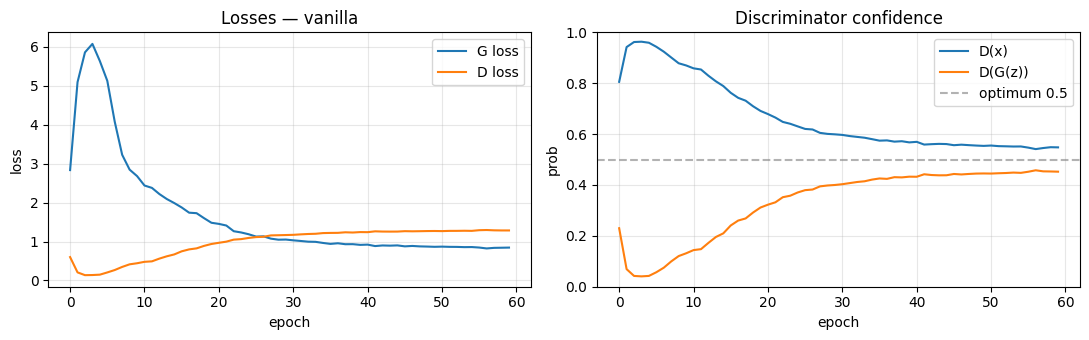

In [9]:
def show_curves(hist: dict, title: str = ''):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    n_per_ep = len(train_loader)
    def _epavg(a):
        a = np.array(a); m = len(a) // n_per_ep * n_per_ep
        return a[:m].reshape(-1, n_per_ep).mean(axis=1)
    g_ep, d_ep = _epavg(hist['g_loss']), _epavg(hist['d_loss'])
    axes[0].plot(g_ep, label='G loss'); axes[0].plot(d_ep, label='D loss')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_title(f'Losses — {title}')

    dx_ep, dgz_ep = _epavg(hist['D_x']), _epavg(hist['D_Gz'])
    axes[1].plot(dx_ep, label='D(x)'); axes[1].plot(dgz_ep, label='D(G(z))')
    axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='optimum 0.5')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('prob'); axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_title('Discriminator confidence')
    plt.tight_layout(); plt.show()

show_curves(hist, title=cfg.tag)

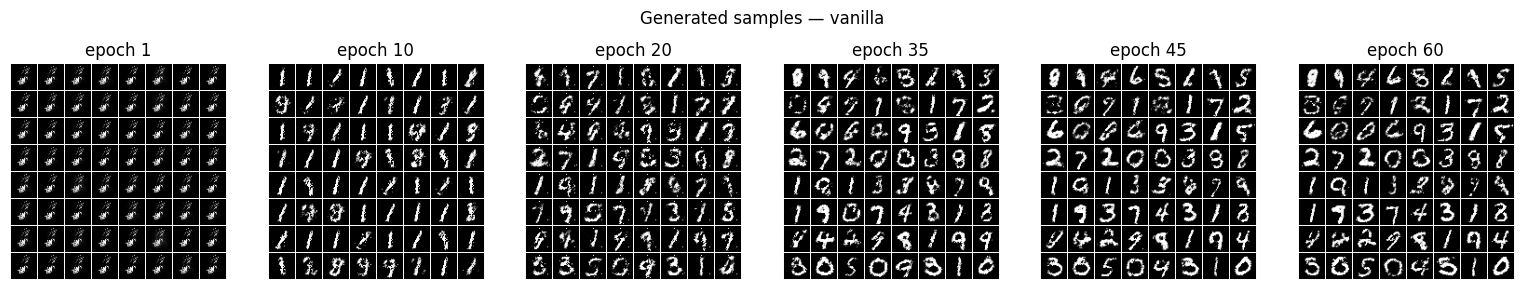

In [10]:
def show_epoch_grid(hist: dict, title: str = ''):
    eps = sorted(hist['epoch_samples'].keys())
    if len(eps) > 6:
        idx = np.linspace(0, len(eps)-1, 6).astype(int)
        eps = [eps[i] for i in idx]
    fig, axes = plt.subplots(1, len(eps), figsize=(2.6*len(eps), 2.8))
    if len(eps) == 1: axes = [axes]
    for ax, ep in zip(axes, eps):
        imgs = hist['epoch_samples'][ep][:64]
        grid = torchvision.utils.make_grid(imgs, nrow=8, padding=1, pad_value=1.0)
        ax.imshow(grid.permute(1,2,0).numpy(), cmap='gray')
        ax.set_title(f'epoch {ep}'); ax.axis('off')
    plt.suptitle(f'Generated samples — {title}', y=1.02)
    plt.tight_layout(); plt.show()

show_epoch_grid(hist, title=cfg.tag)

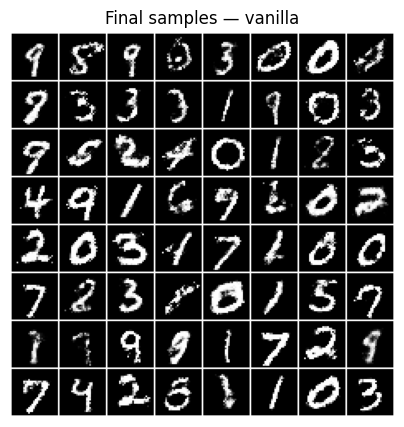

In [11]:
G.eval()
with torch.no_grad():
    imgs = G(sample_z(64)).view(-1, 1, 28, 28).cpu()
grid = torchvision.utils.make_grid(imgs, nrow=8, padding=1, pad_value=1.0)
plt.figure(figsize=(5, 5)); plt.imshow(grid.permute(1,2,0).numpy(), cmap='gray'); plt.axis('off')
plt.title(f'Final samples — {cfg.tag}'); plt.show()

## 8. Parzen window log-likelihood (논문 Table 1)

**아이디어**: G 가 만들어낸 $N$개의 샘플 $\{x_i\}$ 각각에 isotropic Gaussian kernel 을 얹어서 mixture density 를 만든다.
$$\hat p(x) \;=\; \frac{1}{N}\sum_{i=1}^{N} \mathcal{N}(x;\, x_i,\, \sigma^2 I).$$
그리고 test set 의 평균 log-likelihood 를 측정한다.  $\sigma$ 는 validation set 위에서 search 로 고름.

**한계**: Parzen window 추정량은 고차원에서 매우 노이지하고, 시각적 품질과 잘 상관되지 않는다는 게 후속 연구 (Theis et al. 2016) 에서 알려져 있다. 그래도 논문 Table 1 (MNIST: 225 ± 2 nats) 과 직접 비교 가능한 유일한 metric.

log-sum-exp 로 수치 안정화.

In [12]:
def parzen_log_likelihood(samples: torch.Tensor, x_eval: torch.Tensor, sigma: float,
                          batch_eval: int = 100) -> torch.Tensor:
    """평균 log p(x_eval) under Parzen window centered at `samples`.
       samples: [N, D]   (generator 가 만든 샘플, [0,1]^D)
       x_eval : [M, D]   (test data)
    """
    N, D = samples.shape
    samples = samples.to(device)
    norm_const = -0.5 * D * math.log(2 * math.pi * sigma**2)
    out = []
    for i in range(0, x_eval.size(0), batch_eval):
        xb = x_eval[i:i+batch_eval].to(device)                # [m, D]
        diff = xb.unsqueeze(1) - samples.unsqueeze(0)          # [m, N, D]
        sq   = (diff ** 2).sum(dim=-1) / (2 * sigma**2)        # [m, N]
        lp   = torch.logsumexp(-sq, dim=1) - math.log(N) + norm_const
        out.append(lp.cpu())
    return torch.cat(out)

def parzen_eval(G_eval: nn.Module, n_samples: int = 10_000,
                sigmas=(0.10, 0.15, 0.17, 0.20, 0.23, 0.25, 0.30),
                val_size: int = 1000, test_size: Optional[int] = None) -> Dict:
    """논문 절차: G 에서 N 개 샘플 → val 로 sigma search → test 로 평균 log-lik 보고."""
    G_eval.eval()
    with torch.no_grad():
        chunks = []; done = 0
        while done < n_samples:
            b = min(1000, n_samples - done)
            chunks.append(G_eval(sample_z(b)).cpu())
            done += b
        samples = torch.cat(chunks, dim=0)            # [N, 784]

    perm = torch.randperm(len(test_ds))
    val_idx, test_idx = perm[:val_size], perm[val_size:]
    if test_size is not None:
        test_idx = test_idx[:test_size]
    x_val  = torch.stack([test_ds[i][0].view(-1) for i in val_idx])
    x_test = torch.stack([test_ds[i][0].view(-1) for i in test_idx])

    val_means = {}
    for s in sigmas:
        lp = parzen_log_likelihood(samples, x_val, sigma=s)
        val_means[s] = lp.mean().item()
        print(f'  sigma={s:.2f}  val mean log p = {val_means[s]:8.2f} nats')
    sigma_star = max(val_means, key=val_means.get)
    print(f'best sigma on val = {sigma_star:.2f}')

    lp_test = parzen_log_likelihood(samples, x_test, sigma=sigma_star)
    mean = lp_test.mean().item()
    se   = lp_test.std().item() / math.sqrt(len(lp_test))
    return {'sigma': sigma_star, 'mean_logp_test': mean, 'se': se,
            'n_samples': n_samples, 'n_test': len(x_test), 'val_means': val_means}

result_vanilla = parzen_eval(G, n_samples=10_000)
print(f'\nParzen log-likelihood on MNIST test  =  {result_vanilla["mean_logp_test"]:.2f}  ±  {result_vanilla["se"]:.2f}  nats')
print(f'(논문 Table 1 MNIST 보고치: 225 ± 2 nats)')

  sigma=0.10  val mean log p =  -429.52 nats
  sigma=0.15  val mean log p =    88.77 nats
  sigma=0.17  val mean log p =   138.79 nats
  sigma=0.20  val mean log p =   155.90 nats
  sigma=0.23  val mean log p =   138.09 nats
  sigma=0.25  val mean log p =   116.43 nats
  sigma=0.30  val mean log p =    47.09 nats
best sigma on val = 0.20

Parzen log-likelihood on MNIST test  =  153.36  ±  1.71  nats
(논문 Table 1 MNIST 보고치: 225 ± 2 nats)


## 9. 학습 불안정성 — 의도적인 실패 사례

GAN 학습이 잘 안 될 때의 전형적 두 가지 모습을 셋업으로 강제로 재현한다.

1. **Saturating G loss + 강한 D** → G gradient 소실, 학습 정체.
2. **D 과잉 학습 (k=5)** → D 가 너무 빨리 수렴해 G 가 못 따라가는 모습. 흔히 **mode collapse** (G 가 몇 개 모드에만 collapse) 가 동반.

[saturating] epoch   1  d=0.009  g=0.001  D(x)=0.995  D(G(z))=0.002  (4.6s)
[saturating] epoch   2  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.6s)
[saturating] epoch   3  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.6s)
[saturating] epoch   4  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.6s)
[saturating] epoch   5  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.4s)
[saturating] epoch   6  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.4s)
[saturating] epoch   7  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.7s)
[saturating] epoch   8  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.5s)
[saturating] epoch   9  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.9s)
[saturating] epoch  10  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.7s)
[saturating] epoch  11  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.5s)
[saturating] epoch  12  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.6s)
[saturating] epoch  13  d=0.000  g=0.000  D(x)=1.000  D(G(z))=0.000  (4.3s)
[saturating]

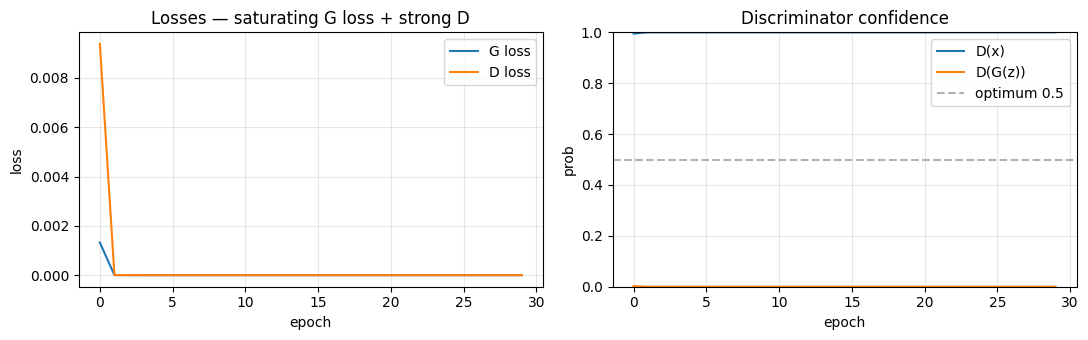

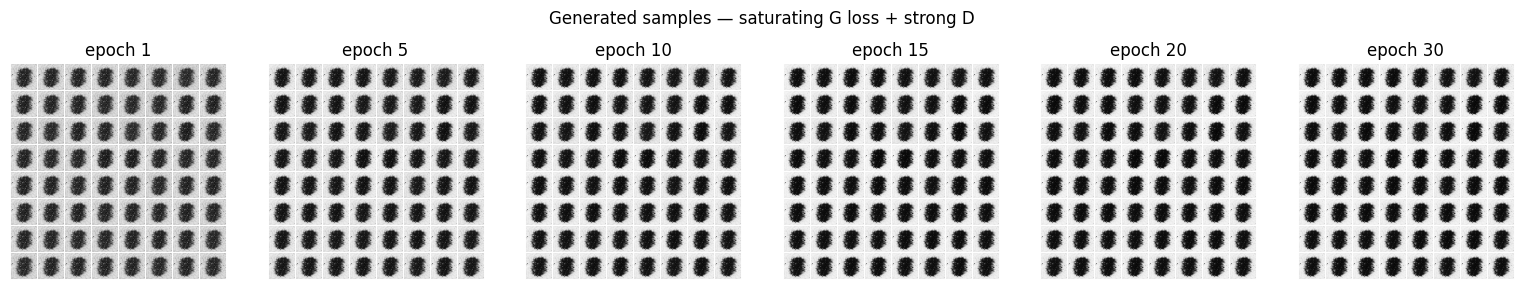

In [13]:
# 9.1  Saturating loss + 큰 D learning rate
cfg_sat = TrainConfig(epochs=30, lr_g=2e-4, lr_d=1e-3, g_loss_type='saturating', tag='saturating')
G_sat, D_sat, hist_sat = train(cfg_sat)
show_curves(hist_sat, title='saturating G loss + strong D')
show_epoch_grid(hist_sat, title='saturating G loss + strong D')

[k=5] epoch   1  d=0.047  g=7.681  D(x)=0.982  D(G(z))=0.013  (12.1s)
[k=5] epoch   2  d=0.041  g=7.699  D(x)=0.989  D(G(z))=0.010  (12.4s)
[k=5] epoch   3  d=0.061  g=6.405  D(x)=0.984  D(G(z))=0.015  (12.1s)
[k=5] epoch   4  d=0.097  g=5.684  D(x)=0.973  D(G(z))=0.024  (11.9s)
[k=5] epoch   5  d=0.111  g=5.062  D(x)=0.970  D(G(z))=0.030  (11.5s)
[k=5] epoch   6  d=0.136  g=4.547  D(x)=0.963  D(G(z))=0.036  (12.0s)
[k=5] epoch   7  d=0.153  g=4.284  D(x)=0.959  D(G(z))=0.040  (12.2s)
[k=5] epoch   8  d=0.185  g=3.900  D(x)=0.950  D(G(z))=0.049  (11.8s)
[k=5] epoch   9  d=0.235  g=3.437  D(x)=0.935  D(G(z))=0.065  (11.9s)
[k=5] epoch  10  d=0.270  g=3.061  D(x)=0.925  D(G(z))=0.076  (12.1s)
[k=5] epoch  11  d=0.284  g=2.929  D(x)=0.921  D(G(z))=0.080  (12.0s)
[k=5] epoch  12  d=0.295  g=2.831  D(x)=0.918  D(G(z))=0.083  (12.4s)
[k=5] epoch  13  d=0.307  g=2.749  D(x)=0.914  D(G(z))=0.087  (12.2s)
[k=5] epoch  14  d=0.321  g=2.622  D(x)=0.911  D(G(z))=0.091  (11.5s)
[k=5] epoch  15  d=0

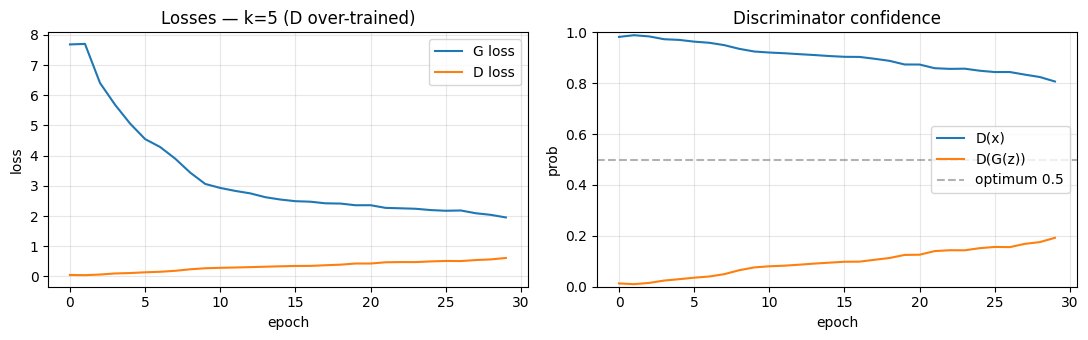

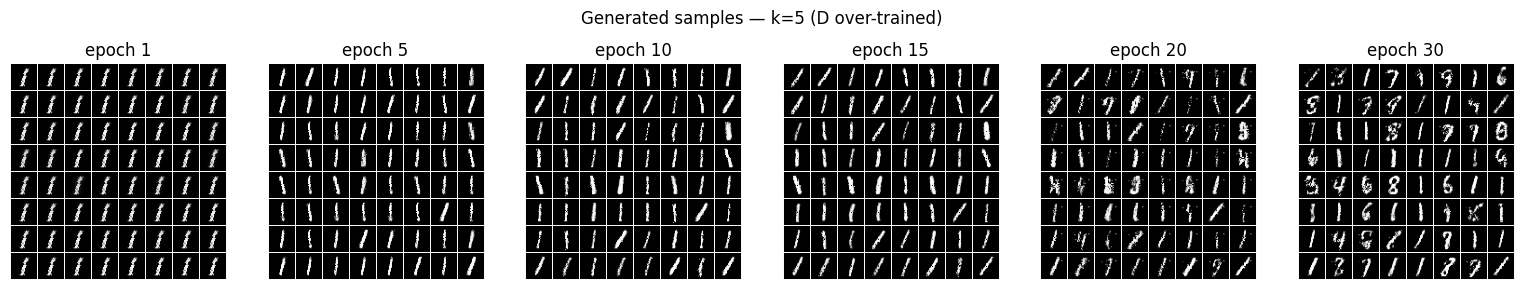

In [14]:
# 9.2  k=5 (D 를 G 보다 5배 더 자주 업데이트)
cfg_k5 = TrainConfig(epochs=30, k_d_steps=5, tag='k=5')
G_k5, D_k5, hist_k5 = train(cfg_k5)
show_curves(hist_k5, title='k=5 (D over-trained)')
show_epoch_grid(hist_k5, title='k=5 (D over-trained)')

### Mode coverage 정량 — classifier 기반

Mode collapse 가 얼마나 심한지 보려면, MNIST classifier 를 따로 학습해서 G 가 만든 1만 개 샘플의 예측 클래스 분포를 본다.  분포가 균등하면 10 모드 다 커버, 한쪽으로 쏠리면 collapse.

In [15]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.net(x)

clf = SmallCNN().to(device)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
for ep in range(3):
    clf.train()
    for x, y in train_loader:
        x = x.to(device); y = y.to(device)
        loss = F.cross_entropy(clf(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
    clf.eval(); correct = 0
    with torch.no_grad():
        for x, y in test_loader:
            correct += (clf(x.to(device)).argmax(-1).cpu() == y).sum().item()
    print(f'classifier epoch {ep+1}  test acc = {correct/len(test_ds)*100:.2f}%')

@torch.no_grad()
def mode_distribution(G_eval: nn.Module, n: int = 10_000) -> np.ndarray:
    G_eval.eval(); clf.eval()
    out = []
    for i in range(0, n, 1000):
        b = min(1000, n - i)
        imgs = G_eval(sample_z(b)).view(-1, 1, 28, 28)
        out.append(clf(imgs).argmax(-1).cpu().numpy())
    preds = np.concatenate(out)
    counts = np.bincount(preds, minlength=10)
    return counts / counts.sum()

classifier epoch 1  test acc = 98.06%
classifier epoch 2  test acc = 98.50%
classifier epoch 3  test acc = 98.79%


,digit,vanilla,saturating,k=5
0,0,8.87%,0.00%,0.86%
1,1,11.74%,0.00%,53.72%
2,2,8.71%,0.00%,1.19%
3,3,10.12%,100.00%,10.62%
4,4,11.67%,0.00%,8.57%
5,5,8.11%,0.00%,4.87%
6,6,9.48%,0.00%,4.21%
7,7,9.78%,0.00%,4.77%
8,8,10.07%,0.00%,5.12%
9,9,11.45%,0.00%,6.07%


/tmp/ipykernel_21560/518114160.py:20: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_21560/518114160.py:20: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_21560/518114160.py:20: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_21560/518114160.py:20: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_21560/518114160.py:20: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_21560/518114160.py:20: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_l

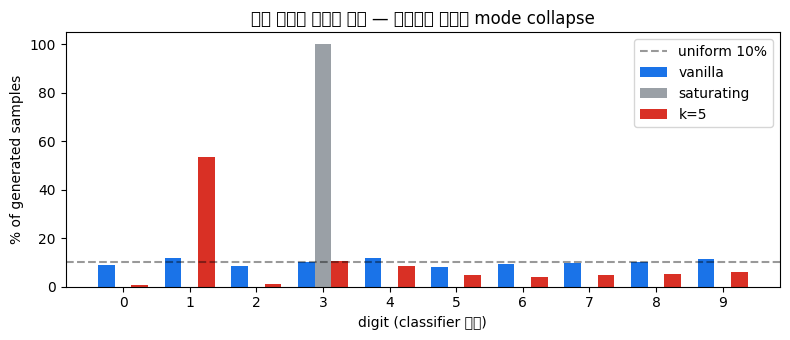

In [16]:
import pandas as pd

modes = pd.DataFrame({
    'digit':      list(range(10)),
    'vanilla':    mode_distribution(G,     n=10_000),
    'saturating': mode_distribution(G_sat, n=10_000),
    'k=5':        mode_distribution(G_k5,  n=10_000),
})
display(modes.style.format({c: '{:.2%}' for c in modes.columns if c != 'digit'}))

fig, ax = plt.subplots(figsize=(8, 3.5))
w = 0.25; x = np.arange(10)
for offset, col, color in [(-w, 'vanilla', '#1a73e8'),
                            (0,   'saturating', '#9aa0a6'),
                            (+w,  'k=5', '#d93025')]:
    ax.bar(x + offset, modes[col].values * 100, width=w, label=col, color=color)
ax.axhline(10, color='black', linestyle='--', alpha=0.4, label='uniform 10%')
ax.set_xticks(x); ax.set_xlabel('digit (classifier 예측)'); ax.set_ylabel('% of generated samples')
ax.set_title('생성 샘플의 클래스 분포 — 균등에서 멀수록 mode collapse')
ax.legend(); plt.tight_layout(); plt.show()

## 10. Latent space interpolation (보너스)

$z$ 공간의 두 점 사이를 선형으로 보간했을 때 샘플이 부드럽게 변하는가 — G 가 단순 memorization 이 아니라 manifold 를 학습했는지 보는 질적 점검.

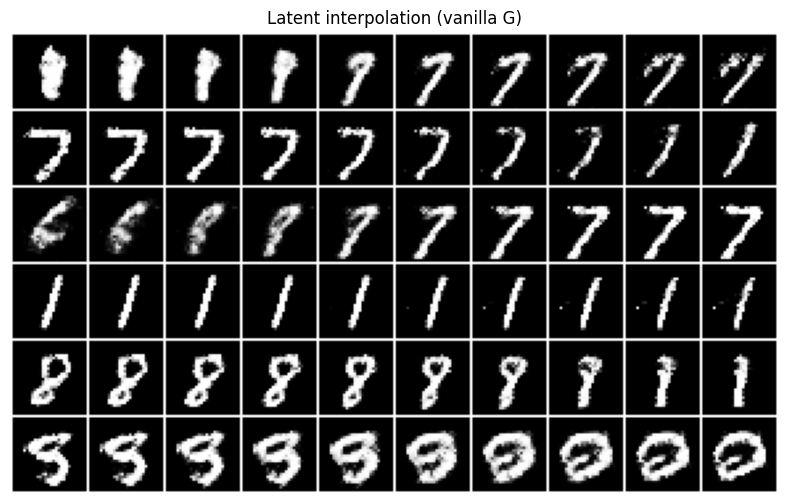

In [17]:
def interpolate(G_eval: nn.Module, n_rows: int = 6, n_steps: int = 10):
    G_eval.eval()
    z0 = sample_z(n_rows); z1 = sample_z(n_rows)
    alphas = torch.linspace(0, 1, n_steps, device=device)
    grid = []
    with torch.no_grad():
        for a in alphas:
            z = (1 - a) * z0 + a * z1
            grid.append(G_eval(z).view(-1, 1, 28, 28).cpu())
    grid = torch.stack(grid, dim=1).reshape(-1, 1, 28, 28)
    return grid, n_steps

grid, n_steps = interpolate(G, n_rows=6, n_steps=10)
img = torchvision.utils.make_grid(grid, nrow=n_steps, padding=1, pad_value=1.0)
plt.figure(figsize=(n_steps, 6)); plt.imshow(img.permute(1,2,0).numpy(), cmap='gray'); plt.axis('off')
plt.title('Latent interpolation (vanilla G)'); plt.show()

## 11. 결과 요약

| Run | Parzen log-lik (nats) | 비고 |
|---|---|---|
| 논문 보고 (MNIST) | 225 ± 2 | Table 1 |
| this run (vanilla) | 셀 8 결과 | Algorithm 1, non-saturating G, k=1, Adam |

그리고 §9 에서 의도적인 셋업으로 만들어낸 실패 사례 — saturating G loss + 강한 D, k=5 — 가 시각적으로도 (샘플 그리드) 정량적으로도 (클래스 분포) 잘 알려진 GAN 학습 병리를 재현함을 확인.

### 더 해볼 만한 것
- **SGD 셋업으로 재현**: 논문 그대로 SGD+momentum 으로 돌려서 lr/momentum 스케줄에 얼마나 민감한지 직접 체험.
- **CIFAR-10 + DCGAN**: vanilla MLP 로는 거의 안 되는 자연 이미지를 CNN G/D 로 옮기면 어떻게 달라지는지.
- **현대 metric (FID, IS)** 로 §9 의 collapse 정도를 정량 비교.
- **Spectral norm / WGAN-GP** 같은 학습 안정화 기법을 같은 코드 위에서 ablation.